In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn import datasets

In [2]:
iris = datasets.load_iris()
X = iris.data
target = iris.target
Y = to_categorical(target).astype("uint8")
# 0 => [1 0 0]
# 1 => [0 1 0]
# 2 => [0 0 1]

In [3]:
idx = 0
print(X[idx])
print(target[idx])
print(Y[idx])

[5.1 3.5 1.4 0.2]
0
[1 0 0]


In [4]:
model = keras.Sequential(
  [
    layers.Dense(3, activation="sigmoid", name="layer1", input_shape=(4,)),
    layers.Dense(3, activation="sigmoid", name="layer2"),
  ]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27 (108.00 B)

 Trainable params: 27 (108.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
y = model(X)
print(y[149])

tf.Tensor([0.24113354 0.5489046  0.51716024], shape=(3,), dtype=float32)


In [6]:
optimizer=tf.keras.optimizers.SGD(learning_rate=0.03)
loss=tf.keras.losses.MeanSquaredError()

model.compile(optimizer, loss)
history = model.fit(X, Y, epochs=500)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2508  
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2497 
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2487 
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2478 
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2468 
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2460 
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2451 
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2443 
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2435 
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2427 
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2420 
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2413 
Epoch 13/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2406 
Epoch 14/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2399 
Epoch 15/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2393 
Epoch 16/500
5/5 ━

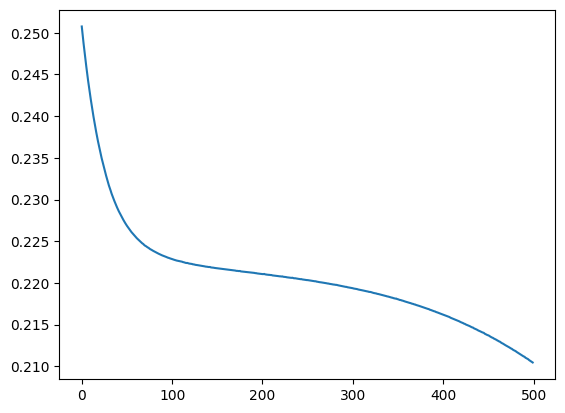

In [7]:
plt.plot(history.history['loss'])
plt.show()

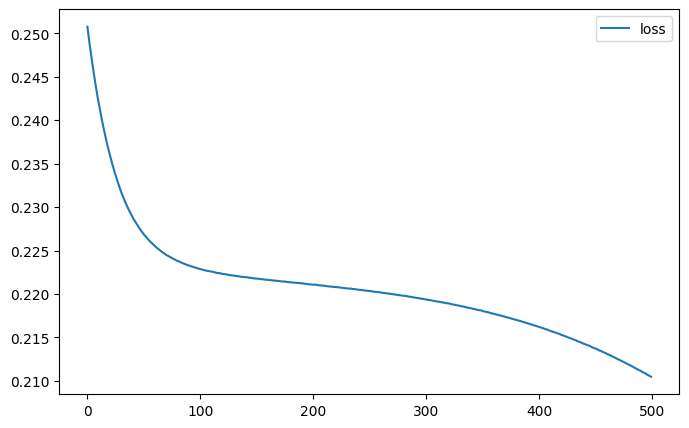

In [8]:
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.show()

In [9]:
model.predict(np.array([[3,3,1,1]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


array([[0.35172293, 0.28259173, 0.285985  ]], dtype=float32)

## Red profunda — topología 4 × 3 × 3 × 3 × 3

Se añaden **dos capas `layers.Dense(3, activation="sigmoid")` extra** antes de la capa de salida (por eso hay 4 capas `Dense` en `model.summary()`). Se mantienen el mismo SGD con η = 0.03, MSE y **500 épocas** que en el modelo original.

In [10]:
model_deep = keras.Sequential(
  [
    layers.Dense(3, activation="sigmoid", name="layer1", input_shape=(4,)),
    layers.Dense(3, activation="sigmoid", name="layer2"),
    layers.Dense(3, activation="sigmoid", name="layer3"),
    layers.Dense(3, activation="sigmoid", name="layer4"),
  ]
)

model_deep.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer4 (Dense)                  │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
optimizer_deep=tf.keras.optimizers.SGD(learning_rate=0.03)
loss_deep=tf.keras.losses.MeanSquaredError()

model_deep.compile(optimizer_deep, loss_deep)
history_deep = model_deep.fit(X, Y, epochs=500)
print('Loss final (500 epocas):', history_deep.history['loss'][-1])


Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2704  
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2695 
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2687 
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2679 
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2671 
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2662 
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2654 
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2646
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2639 
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2631 
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2623 
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2616 
Epoch 13/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2608 
Epoch 14/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2601 
Epoch 15/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2593 
Epoch 16/500
5/5 ━

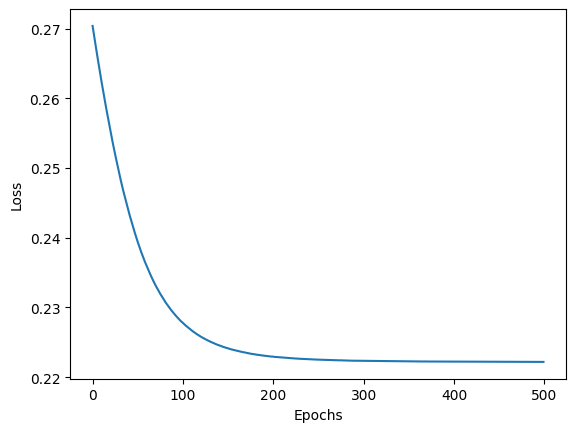

In [12]:
plt.plot(history_deep.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()


## Comparación de curvas

Pérdida (`loss`) por época del modelo original **4 × 3 × 3** y del modelo profundo **4 × 3 × 3 × 3 × 3** (se requiere haber corrido antes la celda de entrenamiento original).

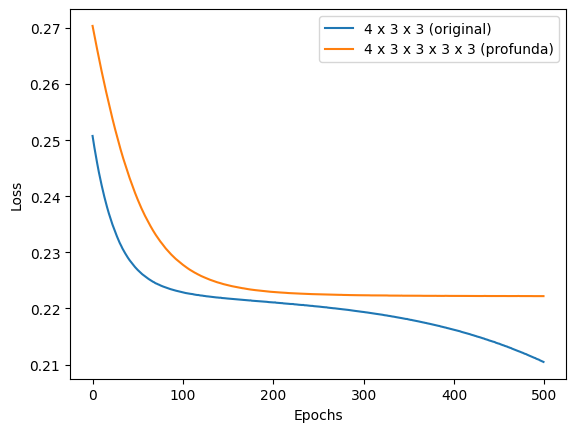

In [13]:
plt.plot(history.history['loss'], label='4 x 3 x 3 (original)')
plt.plot(history_deep.history['loss'], label='4 x 3 x 3 x 3 x 3 (profunda)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [14]:
model_deep.predict(np.array([[3,3,1,1]]))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


array([[0.33530888, 0.3338049 , 0.33539835]], dtype=float32)